# Logistic Regression: The Sigmoid Function

## Why Parametric Models?

The curse of dimensionality makes **local averaging fail in high dimensions**—we cannot reliably count neighbors in a fixed ball when points are far apart.

**Solution:** Use a **parametric model** that assumes a specific functional form for the conditional class probability $P(Y = 1 | X = x)$. This reduces the problem to estimating a few parameters from data, rather than estimating an entire function.

---

## The Logistic Function (Sigmoid)

For binary classification with 1-dimensional input, we model the conditional class probability as:

$$P(Y = 1 | X = x) = \frac{e^{\beta_0 + \beta_1 x}}{1 + e^{\beta_0 + \beta_1 x}}$$

And by probability:

$$P(Y = 0 | X = x) = \frac{1}{1 + e^{\beta_0 + \beta_1 x}}$$

**Key property:** These sum to 1, as they must for a valid probability distribution.

---

## Intuition: Why the Sigmoid Shape?

The sigmoid (S-shaped) function has several desirable properties:

- **Output is always between 0 and 1** ✓ (valid probability)
- **Smooth transition** from 0 to 1 (not discontinuous like a step function)
- **Interpretable:** values closer to 0 or 1 represent confident predictions
- **Asymptotic:** approaches 0 as $x \to -\infty$ and 1 as $x \to +\infty$

---

## Properties of the Sigmoid

**At the center ($x = 0$):**
$$P(Y = 1 | X = 0) = \frac{e^{\beta_0}}{1 + e^{\beta_0}}$$

For the simple case where $\beta_0 = 0$:
$$P(Y = 1 | X = 0) = \frac{1}{1 + 1} = 0.5$$

**As $x \to \infty$:** The exponential $e^{\beta_0 + \beta_1 x}$ dominates the denominator, so $P(Y = 1 | X = x) \to 1$

**As $x \to -\infty$:** The exponential $e^{\beta_0 + \beta_1 x} \to 0$, so $P(Y = 1 | X = x) \to 0$

---

## Parameter Interpretation

### $\beta_1$: Controls the **Steepness** (Rate of Growth)

- **Larger $|\beta_1|$** → steeper sigmoid (quicker transition from 0 to 1)
- **Smaller $|\beta_1|$** → flatter sigmoid (slower, more gradual transition)
- **$\beta_1 > 0$:** The probability increases with $x$
- **$\beta_1 < 0$:** The probability decreases with $x$

Increasing the exponent's coefficient amplifies the rate of change of the sigmoid.

### $\beta_0$: Controls the **Horizontal Shift** (Location)

- **Larger $\beta_0$** → sigmoid shifts right (the 0.5 probability point moves right)
- **Smaller $\beta_0$** → sigmoid shifts left (the 0.5 probability point moves left)

The intercept determines where the function crosses the 0.5 threshold.

---

## Connection to Linear Regression

Notice the exponent: $\beta_0 + \beta_1 x$ is **exactly like a linear regression model**.

The logistic function wraps this linear predictor in a sigmoid to:
1. Constrain output to [0, 1] (valid probabilities)
2. Model non-linear decision boundaries

This is the bridge from linear models to **logistic regression**—a parametric classifier.

---

## Key Takeaways

- **Logistic regression uses the sigmoid function to model $P(Y=1|X=x)$**, avoiding invalid probability estimates and the curse of dimensionality.
- **The sigmoid is S-shaped**: it asymptotically approaches 0 and 1, and always outputs valid probabilities between 0 and 1.
- **$\beta_1$ controls steepness**: larger values create sharper transitions between classes.
- **$\beta_0$ controls horizontal shift**: it determines where the decision boundary crosses 0.5 probability.
- **The exponent is linear**: logistic regression wraps a linear model in a sigmoid to produce valid probabilities.


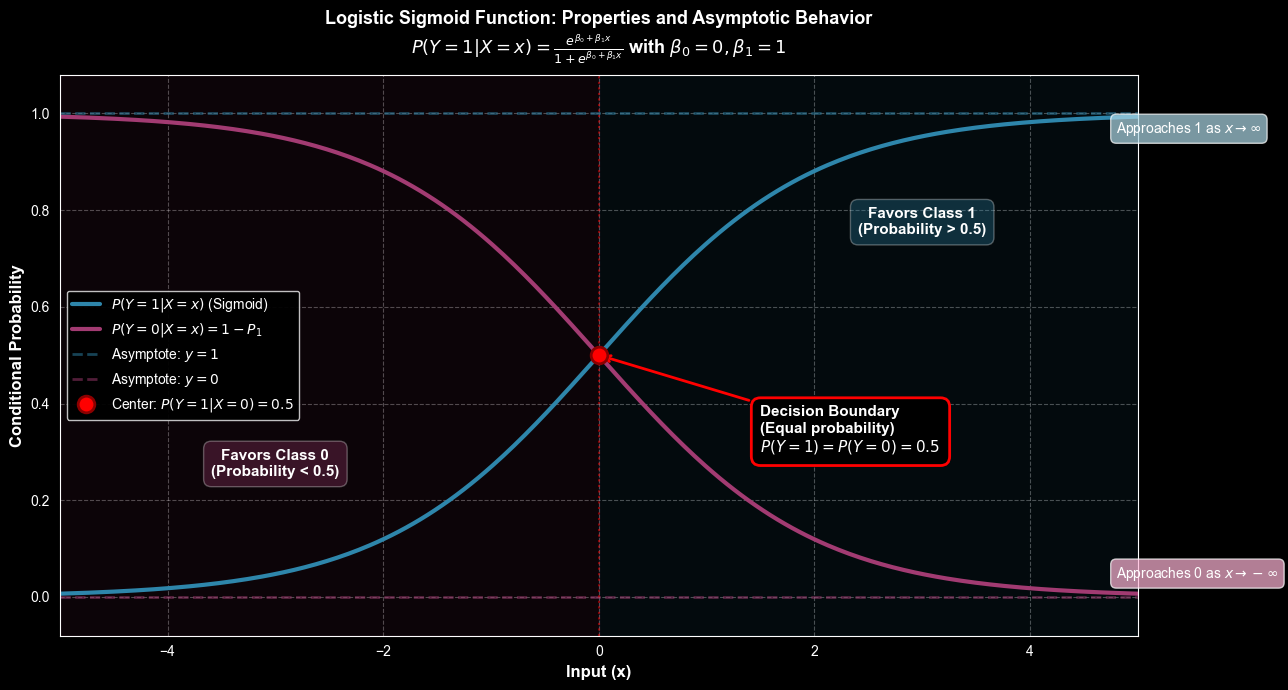

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Define sigmoid function
def sigmoid(x, beta_0, beta_1):
    return np.exp(beta_0 + beta_1 * x) / (1 + np.exp(beta_0 + beta_1 * x))

# Generate x values
x = np.linspace(-5, 5, 300)

# Case: beta_0 = 0, beta_1 = 1 (standard sigmoid)
P_1 = sigmoid(x, beta_0=0, beta_1=1)
P_0 = 1 - P_1

# Create figure
fig, ax = plt.subplots(figsize=(13, 7))

# Plot the sigmoid curves
ax.plot(x, P_1, linewidth=3, color='#2E86AB', label=r'$P(Y=1|X=x)$ (Sigmoid)')
ax.plot(x, P_0, linewidth=3, color='#A23B72', label=r'$P(Y=0|X=x) = 1 - P_1$')

# Add horizontal asymptotes
ax.axhline(y=1, color='#2E86AB', linestyle='--', linewidth=2, alpha=0.5, label='Asymptote: $y = 1$')
ax.axhline(y=0, color='#A23B72', linestyle='--', linewidth=2, alpha=0.5, label='Asymptote: $y = 0$')

# Mark the center point
ax.plot(0, 0.5, 'ro', markersize=12, markeredgewidth=2, markeredgecolor='darkred',
        label='Center: $P(Y=1|X=0) = 0.5$', zorder=5)
ax.axvline(x=0, color='red', linestyle=':', linewidth=1.5, alpha=0.5)

# Add decision boundary annotation
ax.annotate('Decision Boundary\n(Equal probability)\n$P(Y=1) = P(Y=0) = 0.5$',
            xy=(0, 0.5), xytext=(1.5, 0.3), fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            bbox=dict(boxstyle='round,pad=0.6', facecolor='black', edgecolor='red', linewidth=2))

# Shade regions and add interpretive annotations
ax.axvspan(-5, 0, alpha=0.08, color='#A23B72')
ax.axvspan(0, 5, alpha=0.08, color='#2E86AB')

ax.annotate('Favors Class 0\n(Probability < 0.5)',
            xy=(-3, 0.25), fontsize=11, ha='center', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#A23B72', alpha=0.3))
ax.annotate('Favors Class 1\n(Probability > 0.5)',
            xy=(3, 0.75), fontsize=11, ha='center', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#2E86AB', alpha=0.3))

# Add asymptote labels
ax.text(4.8, 0.96, r'Approaches 1 as $x \to \infty$', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.7))
ax.text(4.8, 0.04, r'Approaches 0 as $x \to -\infty$', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFB4D6', alpha=0.7))

# Formatting
ax.set_xlabel('Input (x)', fontsize=12, fontweight='bold')
ax.set_ylabel('Conditional Probability', fontsize=12, fontweight='bold')
ax.set_title('Logistic Sigmoid Function: Properties and Asymptotic Behavior\n' +
             r'$P(Y=1|X=x) = \frac{e^{\beta_0 + \beta_1 x}}{1 + e^{\beta_0 + \beta_1 x}}$ with $\beta_0=0, \beta_1=1$',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='center left', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(-0.08, 1.08)
ax.set_xlim(-5, 5)

plt.tight_layout()
plt.show()

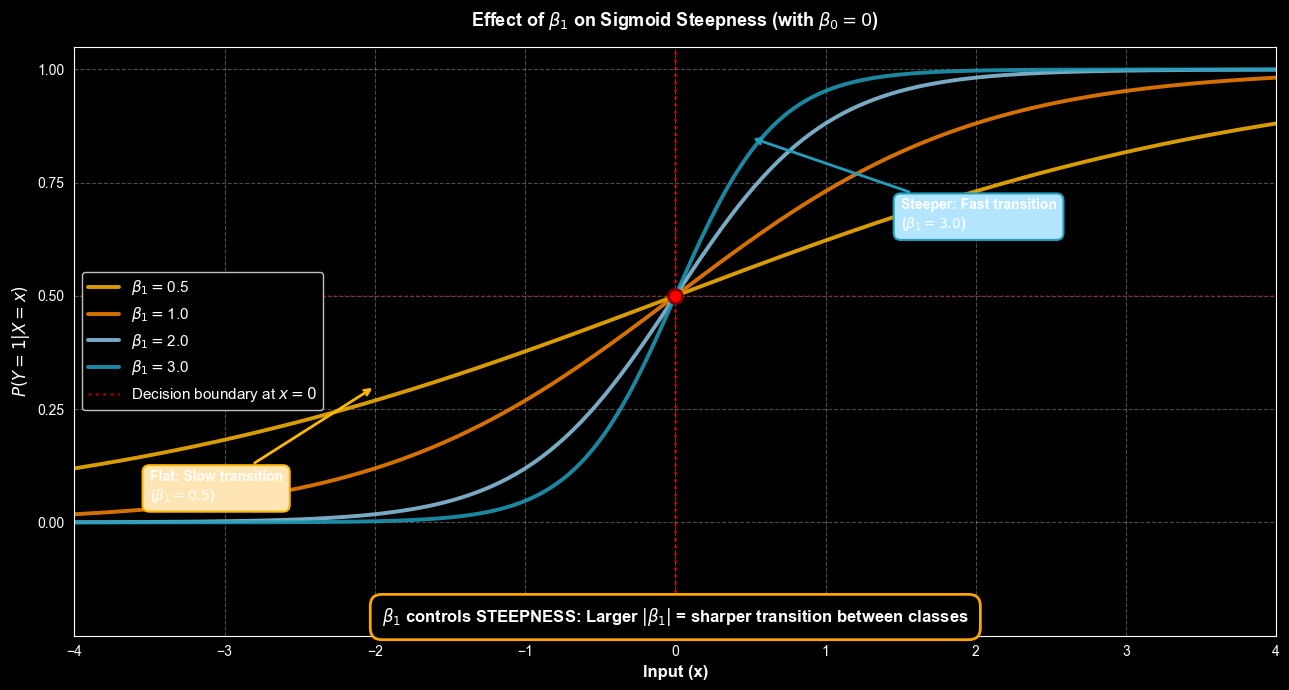

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x, beta_0, beta_1):
    return np.exp(beta_0 + beta_1 * x) / (1 + np.exp(beta_0 + beta_1 * x))

x = np.linspace(-4, 4, 300)

# Different beta_1 values to show steepness effect
beta_1_values = [0.5, 1.0, 2.0, 3.0]
colors = ['#FFB703', '#FB8500', '#8ECAE6', '#219EBC']

# Create figure
fig, ax = plt.subplots(figsize=(13, 7))

# Plot sigmoids with different beta_1 values
for beta_1, color in zip(beta_1_values, colors):
    P_1 = sigmoid(x, beta_0=0, beta_1=beta_1)
    ax.plot(x, P_1, linewidth=2.8, color=color, label=r'$\beta_1 = $' + f'{beta_1}', alpha=0.85)

# Mark center point
ax.axvline(x=0, color='red', linestyle=':', linewidth=2, alpha=0.6, label='Decision boundary at $x=0$')
ax.axhline(y=0.5, color='red', linestyle=':', linewidth=1.5, alpha=0.4)
ax.plot(0, 0.5, 'ro', markersize=10, markeredgewidth=2, markeredgecolor='darkred', zorder=5)

# Annotations showing steepness effect
ax.annotate('Flat: Slow transition\n($\\beta_1 = 0.5$)',
            xy=(-2, 0.3), xytext=(-3.5, 0.05), fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#FFB703', lw=2),
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFE5B4', edgecolor='#FFB703', linewidth=1.5))

ax.annotate('Steeper: Fast transition\n($\\beta_1 = 3.0$)',
            xy=(0.5, 0.85), xytext=(1.5, 0.65), fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#219EBC', lw=2),
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#B4E5FF', edgecolor='#219EBC', linewidth=1.5))

# Add main insight box
ax.text(0, -0.22,
        r'$\beta_1$ controls STEEPNESS: Larger $|\beta_1|$ = sharper transition between classes',
        fontsize=12, fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=0.7', facecolor='black', edgecolor='orange', linewidth=2))

# Formatting
ax.set_xlabel('Input (x)', fontsize=12, fontweight='bold')
ax.set_ylabel(r'$P(Y=1|X=x)$', fontsize=12, fontweight='bold')
ax.set_title(r'Effect of $\beta_1$ on Sigmoid Steepness (with $\beta_0 = 0$)',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='center left', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(-0.25, 1.05)
ax.set_xlim(-4, 4)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])

plt.tight_layout()
plt.show()

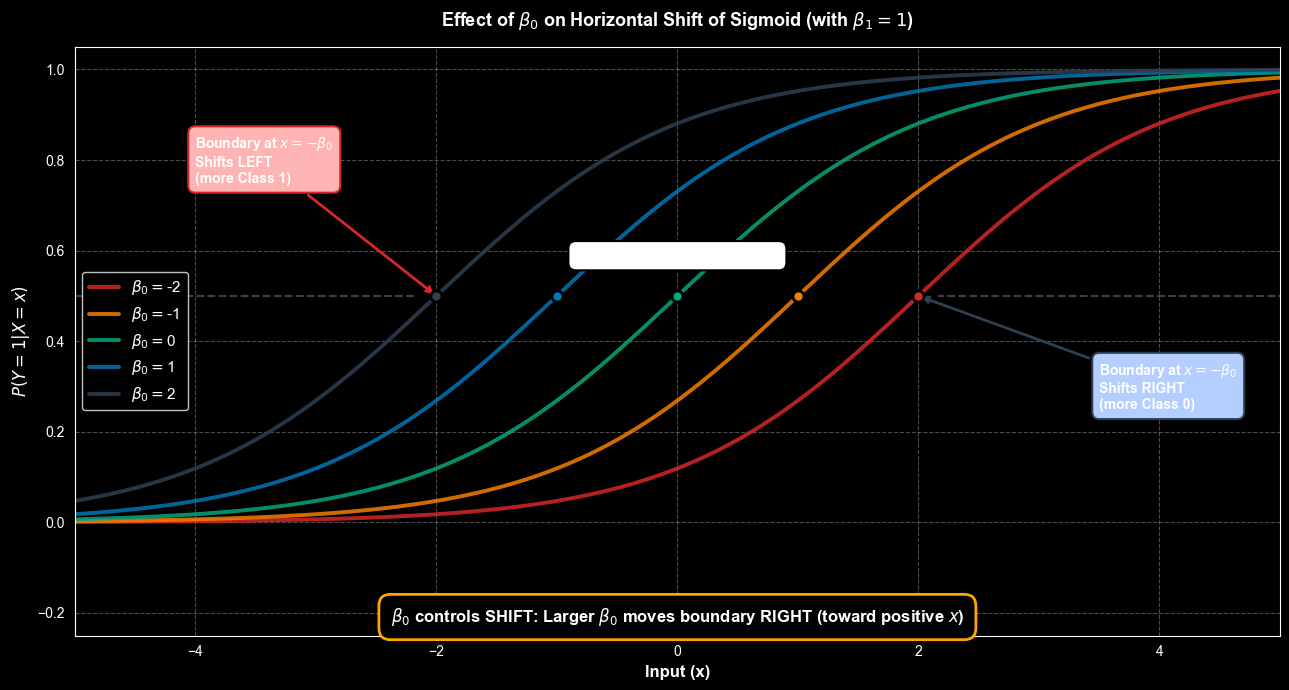

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x, beta_0, beta_1):
    return np.exp(beta_0 + beta_1 * x) / (1 + np.exp(beta_0 + beta_1 * x))

x = np.linspace(-5, 5, 300)

# Different beta_0 values to show shift effect
beta_0_values = [-2, -1, 0, 1, 2]
colors = ['#D62828', '#F77F00', '#06A77D', '#0077B6', '#2E4053']

# Create figure
fig, ax = plt.subplots(figsize=(13, 7))

# Plot sigmoids with different beta_0 values
for beta_0, color in zip(beta_0_values, colors):
    P_1 = sigmoid(x, beta_0=beta_0, beta_1=1)
    ax.plot(x, P_1, linewidth=2.8, color=color, label=r'$\beta_0 = $' + f'{beta_0}', alpha=0.85)

    # Mark where each curve crosses 0.5 (the decision boundary)
    # For our sigmoid, P(Y=1|X=x) = 0.5 when x = -beta_0 / beta_1
    boundary_x = -beta_0 / 1  # Since beta_1 = 1
    ax.plot(boundary_x, 0.5, 'o', color=color, markersize=8, markeredgewidth=2,
            markeredgecolor='black', zorder=5)

# Add reference lines
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)

# Arrows showing direction of shift
ax.annotate('', xy=(2.2, 0.5), xytext=(-2.2, 0.5),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2.5))
ax.text(0, 0.58, r'Decision boundary shifts →', fontsize=11, fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', linewidth=1.5))

# Annotations for specific shift
ax.annotate(r'Boundary at $x = -\beta_0$' + '\nShifts LEFT\n(more Class 1)',
            xy=(-2, 0.5), xytext=(-4, 0.75), fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#D62828', lw=2),
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFB4B4', edgecolor='#D62828', linewidth=1.5))

ax.annotate(r'Boundary at $x = -\beta_0$' + '\nShifts RIGHT\n(more Class 0)',
            xy=(2, 0.5), xytext=(3.5, 0.25), fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#2E4053', lw=2),
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#B4CEFF', edgecolor='#2E4053', linewidth=1.5))

# Main insight
ax.text(0, -0.22,
        r'$\beta_0$ controls SHIFT: Larger $\beta_0$ moves boundary RIGHT (toward positive $x$)',
        fontsize=12, fontweight='bold', ha='center',
bbox=dict(boxstyle='round,pad=0.7', facecolor='black', edgecolor='orange', linewidth=2))
# Formatting
ax.set_xlabel('Input (x)', fontsize=12, fontweight='bold')
ax.set_ylabel(r'$P(Y=1|X=x)$', fontsize=12, fontweight='bold')
ax.set_title(r'Effect of $\beta_0$ on Horizontal Shift of Sigmoid (with $\beta_1 = 1$)',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='center left', fontsize=11, framealpha=0.95, ncol=1)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(-0.25, 1.05)
ax.set_xlim(-5, 5)

plt.tight_layout()
plt.show()

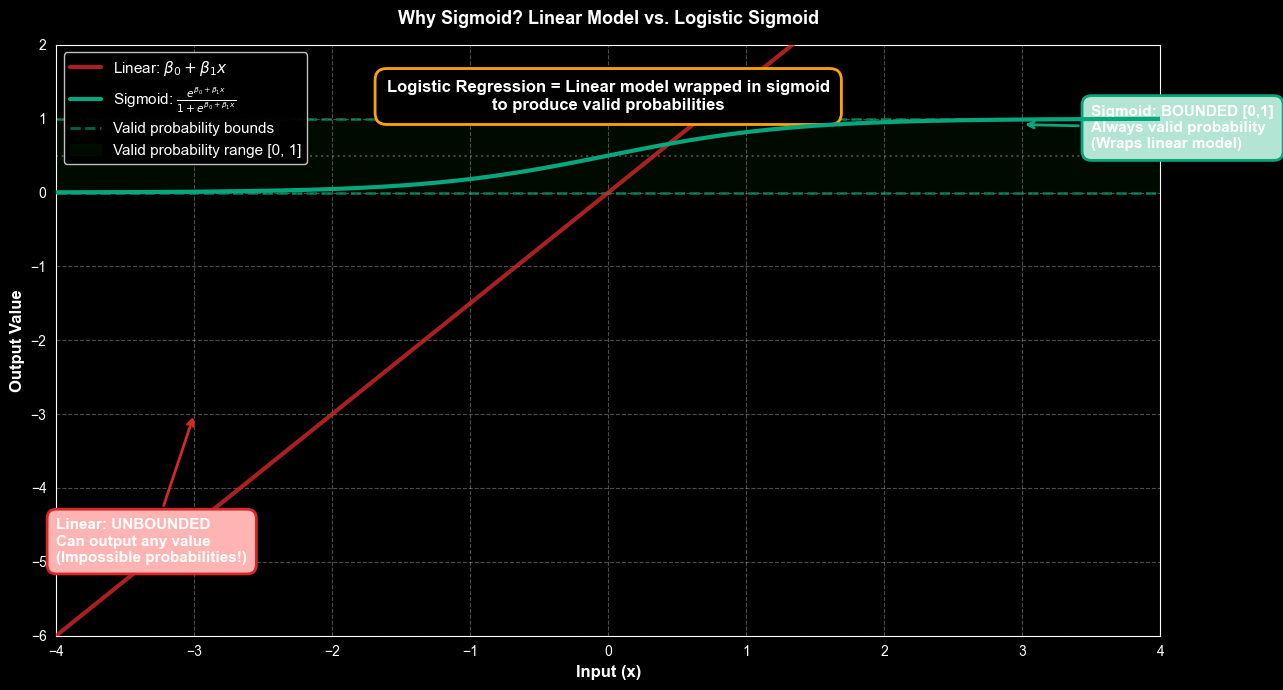

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x, beta_0, beta_1):
    return np.exp(beta_0 + beta_1 * x) / (1 + np.exp(beta_0 + beta_1 * x))

x = np.linspace(-4, 4, 300)
beta_0, beta_1 = 0, 1.5

# Linear model output (unbounded)
linear_output = beta_0 + beta_1 * x

# Sigmoid output (bounded)
sigmoid_output = sigmoid(x, beta_0, beta_1)

# Create figure
fig, ax = plt.subplots(figsize=(13, 7))

# Plot both
ax.plot(x, linear_output, linewidth=3, color='#D62828', label=r'Linear: $\beta_0 + \beta_1 x$',
        linestyle='-', alpha=0.8, zorder=3)
ax.plot(x, sigmoid_output, linewidth=3, color='#06A77D', label=r'Sigmoid: $\frac{e^{\beta_0 + \beta_1 x}}{1 + e^{\beta_0 + \beta_1 x}}$',
        zorder=4)

# Add probability bounds
ax.axhline(y=1, color='#06A77D', linestyle='--', linewidth=2, alpha=0.6, label='Valid probability bounds')
ax.axhline(y=0, color='#06A77D', linestyle='--', linewidth=2, alpha=0.6)
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.5)

# Shade the valid probability region
ax.axhspan(0, 1, alpha=0.08, color='green', label='Valid probability range [0, 1]')

# Annotations
ax.annotate('Linear: UNBOUNDED\nCan output any value\n(Impossible probabilities!)',
            xy=(-3, -3), xytext=(-4, -5), fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#D62828', lw=2),
            bbox=dict(boxstyle='round,pad=0.6', facecolor='#FFB4B4', edgecolor='#D62828', linewidth=2))

ax.annotate('Sigmoid: BOUNDED [0,1]\nAlways valid probability\n(Wraps linear model)',
            xy=(3, 0.92), xytext=(3.5, 0.6), fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#06A77D', lw=2),
            bbox=dict(boxstyle='round,pad=0.6', facecolor='#B4E5D4', edgecolor='#06A77D', linewidth=2))

ax.text(0, 1.12, 'Logistic Regression = Linear model wrapped in sigmoid\nto produce valid probabilities',
        fontsize=12, fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=0.7', facecolor='black', edgecolor='orange', linewidth=2))

# Formatting
ax.set_xlabel('Input (x)', fontsize=12, fontweight='bold')
ax.set_ylabel('Output Value', fontsize=12, fontweight='bold')
ax.set_title(r'Why Sigmoid? Linear Model vs. Logistic Sigmoid',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(-6, 2)
ax.set_xlim(-4, 4)

plt.tight_layout()
plt.show()

# Maximum Likelihood Estimation for Logistic Regression

## The Problem We're Solving

Given a dataset of input-output pairs $(x_i, y_i)$, we want to **estimate the unknown parameters $\beta_0$ and $\beta_1$** that nature used to generate the data.

We **assume nature generated the data using a logistic function**, but we don't know the true values of $\beta_0$ and $\beta_1$.

**Strategy:** Use the data to find parameter estimates $\hat{\beta}_0$ and $\hat{\beta}_1$ that best explain what we observed.

---

## The Likelihood Function

### What Is Likelihood?

The **likelihood function** is the conditional probability of observing the entire dataset, given the inputs and the unknown parameters $\theta_0$ and $\theta_1$:

$$L(\theta_0, \theta_1 | \text{data}) = P(Y = y_1, Y = y_2, \ldots, Y = y_n | X = x_1, X = x_2, \ldots, X = x_n)$$

### For One Data Point

For a single pair $(x_i, y_i)$, the conditional probability depends on whether $y_i = 1$ or $y_i = 0$:

$$P(Y = y_i | X = x_i) = \begin{cases}
P_1(x_i) & \text{if } y_i = 1 \\
P_0(x_i) & \text{if } y_i = 0
\end{cases}$$

where $P_1(x_i) = \frac{e^{\theta_0 + \theta_1 x_i}}{1 + e^{\theta_0 + \theta_1 x_i}}$ and $P_0(x_i) = 1 - P_1(x_i)$

### For the Entire Dataset (Independence Assumption)

Assuming data points are generated **independently**, the likelihood function is the **product** of individual probabilities:

$$L(\theta_0, \theta_1) = \prod_{i=1}^{n} P(Y = y_i | X = x_i)$$

We can separate this product into two groups:
- **Points where $y_i = 1$:** use $P_1(x_i)$
- **Points where $y_i = 0$:** use $P_0(x_i)$

$$L(\theta_0, \theta_1) = \left[\prod_{y_i = 1} P_1(x_i)\right] \times \left[\prod_{y_i = 0} P_0(x_i)\right]$$

**Key insight:** The likelihood **depends only on unknown parameters** $\theta_0$ and $\theta_1$. The data $(x_i, y_i)$ is fixed.

---

## Maximum Likelihood Estimation (MLE)

### The Principle

The **maximum likelihood estimator** chooses parameter values that **maximize the likelihood function**:

$$(\hat{\beta}_0, \hat{\beta}_1) = \arg\max_{\theta_0, \theta_1} L(\theta_0, \theta_1)$$

**Intuition:** Find the parameter values that make the observed data **most likely to occur**.

In practice, we find $\hat{\beta}_0$ and $\hat{\beta}_1$ by optimizing (taking derivatives, setting to zero, solving numerically).

---

## Example: Default Dataset

### The Data

The Default dataset contains credit card data:
- **Output ($y$):** Did the person default on credit? (1 = Default, 0 = No default)
- **Inputs ($x$):** Balance (account balance) and Income

### Which Input Matters?

**Income:** NOT predictive. Across all income levels, the fraction of defaults is roughly the same.

**Balance:** HIGHLY predictive.
- Low balance → Low probability of default
- High balance → High probability of default

**Conclusion:** Use only **Balance** as the predictor for logistic regression.

### Fitted Logistic Regression

Running MLE on the Default dataset gives:

$$\hat{\beta}_0 = -10.65 \quad (\text{SE} = 0.36)$$
$$\hat{\beta}_1 = 0.0055 \quad (\text{SE} = 0.0002)$$

**Standard Error (SE):** Measures uncertainty in our estimates. Larger SE = more variability in $\hat{\beta}_i$ across different samples.

(These standard errors relate to sampling distributions and confidence intervals—similar to what we saw in regression.)

### Making Predictions

With estimated parameters, we can predict the probability of default for any balance:

$$\hat{P}_1(\text{Balance}) = \frac{e^{-10.65 + 0.0055 \cdot \text{Balance}}}{1 + e^{-10.65 + 0.0055 \cdot \text{Balance}}}$$

**Numerical examples:**
- **Balance = $1,000:** $\hat{P}_1 = 0.006$ (0.6% chance of default)
- **Balance = $2,000:** $\hat{P}_1 = 0.58$ (58% chance of default)

A doubling of balance dramatically increases the predicted default probability.

---

## Key Insights

### Why Maximum Likelihood?

1. **Interpretable:** Find parameters that make observed data most probable
2. **Principled:** Works for any parametric model (logistic, linear, etc.)
3. **Statistical properties:** MLE estimates are consistent, asymptotically normal, and efficient

### Standard Errors in Logistic Regression

Just like in linear regression, $\hat{\beta}_i$ estimates are **random variables** with standard errors. This lets us:
- Construct confidence intervals for true parameters
- Perform hypothesis tests (does this coefficient matter?)
- Quantify uncertainty in predictions

---

## Connection to Previous Topics

$$\text{Sigmoid function} \rightarrow \text{Likelihood function} \rightarrow \text{MLE optimization} \rightarrow \hat{\beta}_0, \hat{\beta}_1 \rightarrow \text{Standard errors} \rightarrow \text{Confidence intervals}$$

---

## Key Takeaways

- **Likelihood = probability of observed data given parameters.** It's the bridge from data to parameter estimation.
- **Maximum Likelihood finds parameters that maximize the likelihood—they make the observed data most probable.**
- **Independence assumption:** The likelihood is a product because data points are independent.
- **Standard errors quantify uncertainty** in parameter estimates $\hat{\beta}_i$; they measure the sampling variability.
- **Predictions are made by plugging estimated parameters into the sigmoid:** $\hat{P}_1(x) = \frac{e^{\hat{\beta}_0 + \hat{\beta}_1 x}}{1 + e^{\hat{\beta}_0 + \hat{\beta}_1 x}}$
- **Real example:** Balance is a strong predictor of credit default; doubling balance → ~10x increase in default probability.

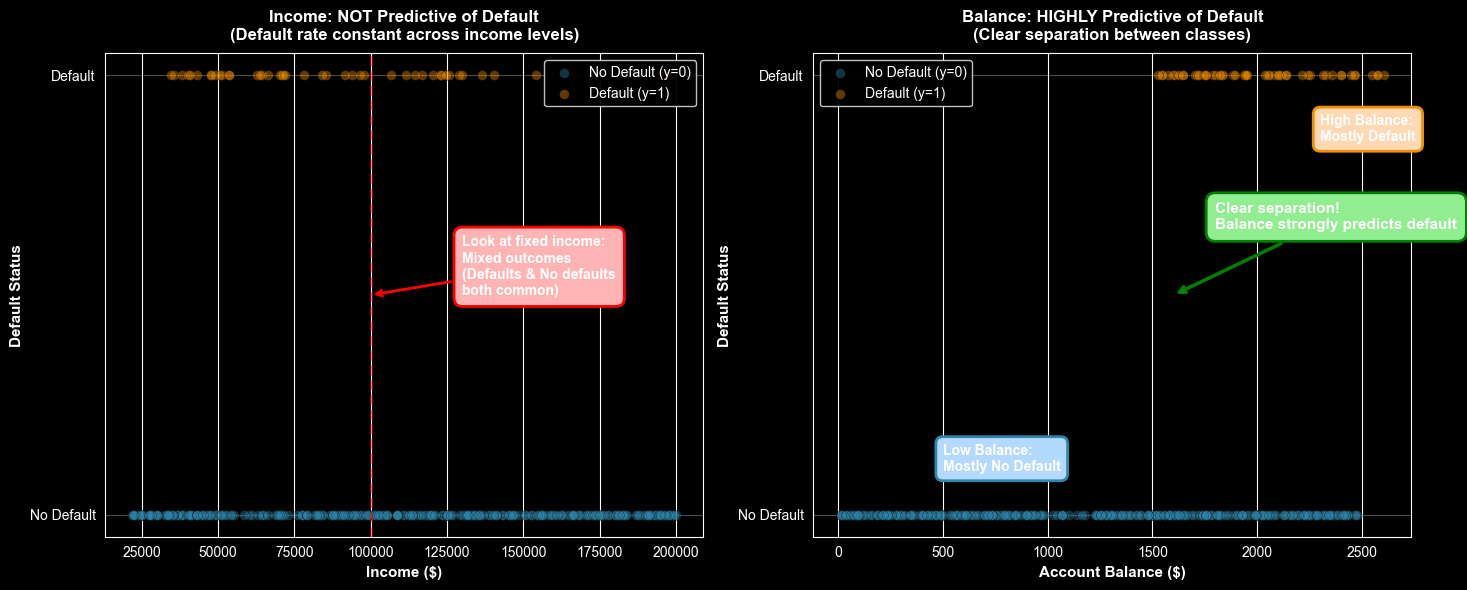

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Simulate Default dataset
np.random.seed(42)
n_no_default = 300
n_default = 50

# No default (y=0): lower balance, random income
balance_0 = np.random.uniform(0, 2500, n_no_default)
income_0 = np.random.uniform(20000, 200000, n_no_default)
y_0 = np.zeros(n_no_default)

# Default (y=1): higher balance, random income
balance_1 = np.random.uniform(1500, 2700, n_default)
income_1 = np.random.uniform(20000, 200000, n_default)
y_1 = np.ones(n_default)

# Combine
balance = np.concatenate([balance_0, balance_1])
income = np.concatenate([income_0, income_1])
y = np.concatenate([y_0, y_1])

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- LEFT PLOT: Income vs Default Rate ---
ax1.scatter(income[y == 0], np.zeros_like(income[y == 0]), alpha=0.4, s=50,
            color='#2E86AB', label='No Default (y=0)', edgecolors='black', linewidth=0.5)
ax1.scatter(income[y == 1], np.ones_like(income[y == 1]), alpha=0.4, s=50,
            color='#F18F01', label='Default (y=1)', edgecolors='black', linewidth=0.5)

# Add annotation showing why income doesn't work
income_slice = 100000
ax1.axvline(x=income_slice, color='red', linestyle='--', linewidth=2, alpha=0.5)
defaults_at_slice = np.sum((income == income_slice) & (y == 1))
no_defaults_at_slice = np.sum((income == income_slice) & (y == 0))
ax1.annotate('Look at fixed income:\nMixed outcomes\n(Defaults & No defaults\nboth common)',
             xy=(income_slice, 0.5), xytext=(130000, 0.5), fontsize=10, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             bbox=dict(boxstyle='round,pad=0.6', facecolor='#FFB4B4', edgecolor='red', linewidth=2))

ax1.set_xlabel('Income ($)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Default Status', fontsize=11, fontweight='bold')
ax1.set_title('Income: NOT Predictive of Default\n(Default rate constant across income levels)',
              fontsize=12, fontweight='bold', pad=10)
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['No Default', 'Default'])
ax1.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax1.grid(True, alpha=0.3, axis='y')

# --- RIGHT PLOT: Balance vs Default Rate ---
ax2.scatter(balance[y == 0], np.zeros_like(balance[y == 0]), alpha=0.4, s=50,
            color='#2E86AB', label='No Default (y=0)', edgecolors='black', linewidth=0.5)
ax2.scatter(balance[y == 1], np.ones_like(balance[y == 1]), alpha=0.4, s=50,
            color='#F18F01', label='Default (y=1)', edgecolors='black', linewidth=0.5)

# Add annotations showing clear separation
ax2.annotate('Low Balance:\nMostly No Default',
             xy=(500, 0.1), fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#B4D9FF', edgecolor='#2E86AB', linewidth=2))
ax2.annotate('High Balance:\nMostly Default',
             xy=(2300, 0.85), fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFD9B4', edgecolor='#F18F01', linewidth=2))
ax2.annotate('Clear separation!\nBalance strongly predicts default',
             xy=(1600, 0.5), xytext=(1800, 0.65), fontsize=11, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='green', lw=2.5),
             bbox=dict(boxstyle='round,pad=0.6', facecolor='lightgreen', edgecolor='green', linewidth=2))

ax2.set_xlabel('Account Balance ($)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Default Status', fontsize=11, fontweight='bold')
ax2.set_title('Balance: HIGHLY Predictive of Default\n(Clear separation between classes)',
              fontsize=12, fontweight='bold', pad=10)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['No Default', 'Default'])
ax2.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

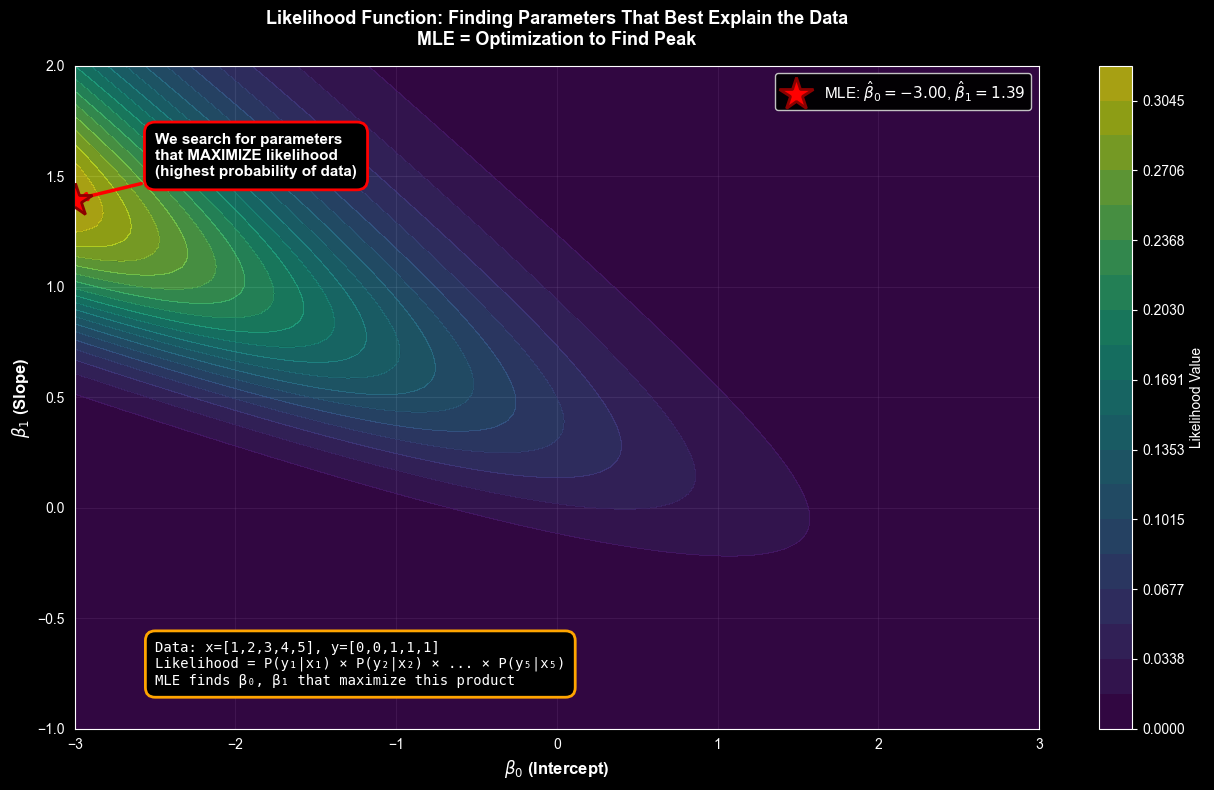

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Simple example: 5 data points
np.random.seed(42)
x = np.array([1, 2, 3, 4, 5])
y = np.array([0, 0, 1, 1, 1])  # 2 defaults, 3 no-defaults

def sigmoid(z):
    return np.exp(z) / (1 + np.exp(z))

def likelihood(beta_0, beta_1, x, y):
    """Compute likelihood for given parameters"""
    log_odds = beta_0 + beta_1 * x
    p1 = sigmoid(log_odds)
    p0 = 1 - p1

    # Likelihood is product of probabilities
    likelihood_val = 1.0
    for xi, yi in zip(x, y):
        if yi == 1:
            likelihood_val *= sigmoid(beta_0 + beta_1 * xi)
        else:
            likelihood_val *= (1 - sigmoid(beta_0 + beta_1 * xi))
    return likelihood_val

# Create grid of parameters
beta_0_range = np.linspace(-3, 3, 100)
beta_1_range = np.linspace(-1, 2, 100)
B0, B1 = np.meshgrid(beta_0_range, beta_1_range)
L = np.zeros_like(B0)

for i in range(len(beta_0_range)):
    for j in range(len(beta_1_range)):
        L[j, i] = likelihood(B0[j, i], B1[j, i], x, y)

# Find maximum
max_idx = np.unravel_index(np.argmax(L), L.shape)
max_beta_0 = B0[max_idx]
max_beta_1 = B1[max_idx]
max_likelihood = L[max_idx]

# Create figure
fig, ax = plt.subplots(figsize=(13, 8))

# Plot likelihood surface as contours
contour_levels = np.linspace(L.min(), L.max(), 20)
cf = ax.contourf(B0, B1, L, levels=contour_levels, cmap='viridis', alpha=0.7)
contour_lines = ax.contour(B0, B1, L, levels=contour_levels[::2], colors='black', alpha=0.2, linewidths=0.5)

# Mark the maximum
ax.plot(max_beta_0, max_beta_1, 'r*', markersize=25, markeredgewidth=2, markeredgecolor='darkred',
        label=f'MLE: $\\hat{{\\beta}}_0={max_beta_0:.2f}$, $\\hat{{\\beta}}_1={max_beta_1:.2f}$', zorder=5)

# Add colorbar
cbar = plt.colorbar(cf, ax=ax, label='Likelihood Value')

# Annotations explaining MLE
ax.annotate('We search for parameters\nthat MAXIMIZE likelihood\n(highest probability of data)',
            xy=(max_beta_0, max_beta_1), xytext=(-2.5, 1.5), fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=2.5),
            bbox=dict(boxstyle='round,pad=0.7', facecolor='black', edgecolor='red', linewidth=2))

ax.text(-2.5, -0.8,
        'Data: x=[1,2,3,4,5], y=[0,0,1,1,1]\n' +
        'Likelihood = P(y₁|x₁) × P(y₂|x₂) × ... × P(y₅|x₅)\n' +
        'MLE finds β₀, β₁ that maximize this product',
        fontsize=10, fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.7', facecolor='black', edgecolor='orange', linewidth=2))

# Formatting
ax.set_xlabel('$\\beta_0$ (Intercept)', fontsize=12, fontweight='bold')
ax.set_ylabel('$\\beta_1$ (Slope)', fontsize=12, fontweight='bold')
ax.set_title('Likelihood Function: Finding Parameters That Best Explain the Data\nMLE = Optimization to Find Peak',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

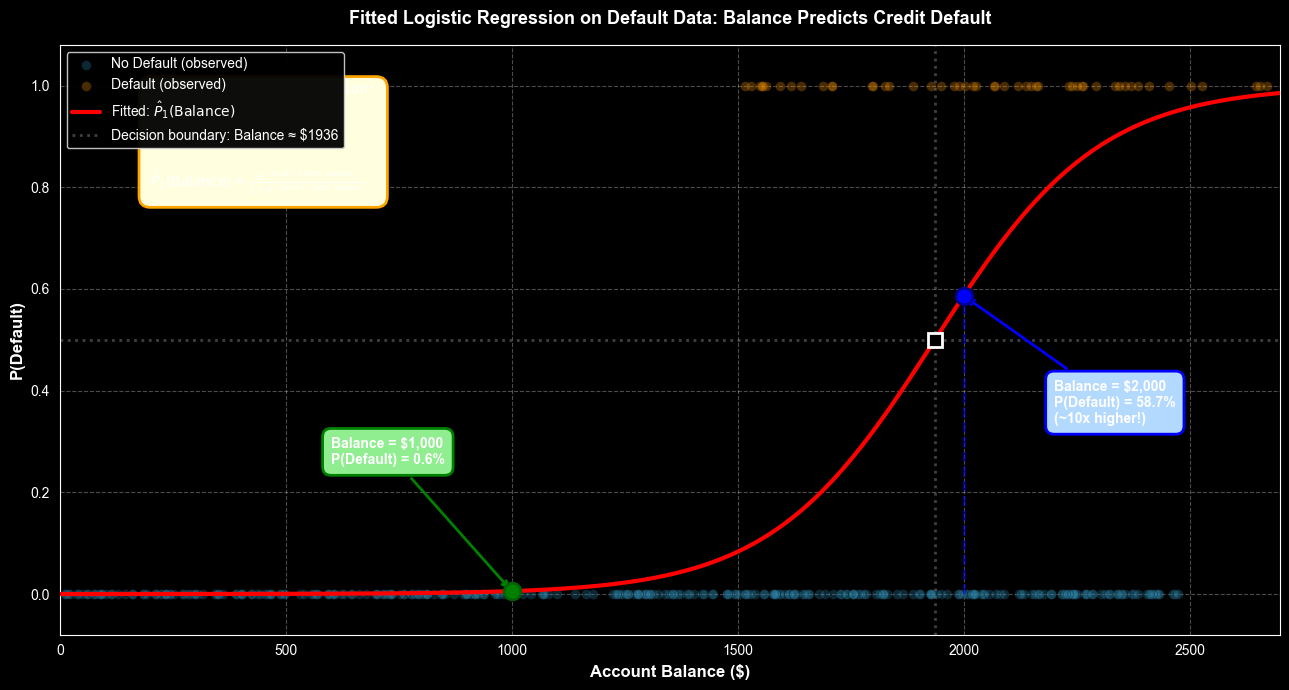

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate Default dataset
np.random.seed(42)
n_no_default = 300
n_default = 50

balance_0 = np.random.uniform(0, 2500, n_no_default)
y_0 = np.zeros(n_no_default)

balance_1 = np.random.uniform(1500, 2700, n_default)
y_1 = np.ones(n_default)

balance = np.concatenate([balance_0, balance_1])
y = np.concatenate([y_0, y_1])

# Fitted logistic regression coefficients (from lecture)
beta_0_hat = -10.65
beta_1_hat = 0.0055

# Fitted logistic function
def fitted_logistic(x):
    return np.exp(beta_0_hat + beta_1_hat * x) / (1 + np.exp(beta_0_hat + beta_1_hat * x))

# Create figure
fig, ax = plt.subplots(figsize=(13, 7))

# Plot data points
ax.scatter(balance[y == 0], y[y == 0], alpha=0.3, s=50,
           color='#2E86AB', label='No Default (observed)', edgecolors='black', linewidth=0.5)
ax.scatter(balance[y == 1], y[y == 1], alpha=0.3, s=50,
           color='#F18F01', label='Default (observed)', edgecolors='black', linewidth=0.5)

# Plot fitted logistic curve
x_smooth = np.linspace(0, 2700, 300)
p_hat = fitted_logistic(x_smooth)
ax.plot(x_smooth, p_hat, linewidth=3, color='red', label=r'Fitted: $\hat{P}_1(\text{Balance})$', zorder=4)

# Highlight key predictions
# Example 1: Balance = $1,000
balance_1k = 1000
p_1k = fitted_logistic(balance_1k)
ax.plot(balance_1k, p_1k, 'go', markersize=12, markeredgewidth=2, markeredgecolor='darkgreen', zorder=5)
ax.vlines(balance_1k, 0, p_1k, colors='green', linestyles='--', linewidth=2, alpha=0.5)
ax.annotate(f'Balance = $1,000\nP(Default) = {p_1k:.1%}',
            xy=(balance_1k, p_1k), xytext=(balance_1k - 400, p_1k + 0.25), fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            bbox=dict(boxstyle='round,pad=0.6', facecolor='lightgreen', edgecolor='green', linewidth=2))

# Example 2: Balance = $2,000
balance_2k = 2000
p_2k = fitted_logistic(balance_2k)
ax.plot(balance_2k, p_2k, 'bo', markersize=12, markeredgewidth=2, markeredgecolor='darkblue', zorder=5)
ax.vlines(balance_2k, 0, p_2k, colors='blue', linestyles='--', linewidth=2, alpha=0.5)
ax.annotate(f'Balance = $2,000\nP(Default) = {p_2k:.1%}\n(~10x higher!)',
            xy=(balance_2k, p_2k), xytext=(balance_2k + 200, p_2k - 0.25), fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='blue', lw=2),
            bbox=dict(boxstyle='round,pad=0.6', facecolor='#B4D9FF', edgecolor='blue', linewidth=2))

# Add decision boundary at P = 0.5
decision_balance = -beta_0_hat / beta_1_hat
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=2, alpha=0.5)
ax.axvline(x=decision_balance, color='gray', linestyle=':', linewidth=2, alpha=0.5,
           label=f'Decision boundary: Balance ≈ ${decision_balance:.0f}')
ax.plot(decision_balance, 0.5, 'ks', markersize=10, markeredgewidth=2, markeredgecolor='white', zorder=5)

# Add text box with fitted equation
eq_text = (f'Fitted Logistic Regression:\n'
           f'$\\hat{{\\beta}}_0 = {beta_0_hat:.2f}$ (SE = 0.36)\n'
           f'$\\hat{{\\beta}}_1 = {beta_1_hat:.4f}$ (SE = 0.0002)\n\n'
           f'$\\hat{{P}}_1(\\text{{Balance}}) = \\frac{{e^{{{beta_0_hat:.2f} + {beta_1_hat:.4f} \\cdot \\text{{Balance}}}}}}{{1 + e^{{{beta_0_hat:.2f} + {beta_1_hat:.4f} \\cdot \\text{{Balance}}}}}}$')
ax.text(200, 0.8, eq_text, fontsize=10, fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='lightyellow', edgecolor='orange', linewidth=2))

# Formatting
ax.set_xlabel('Account Balance ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('P(Default)', fontsize=12, fontweight='bold')
ax.set_title('Fitted Logistic Regression on Default Data: Balance Predicts Credit Default',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(-0.08, 1.08)
ax.set_xlim(0, 2700)

plt.tight_layout()
plt.show()

/var/folders/rb/gp9fvqns4977ldbmtv4_70w80000gn/T/ipykernel_7481/2297282593.py:87: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rb/gp9fvqns4977ldbmtv4_70w80000gn/T/ipykernel_7481/2297282593.py:87: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()


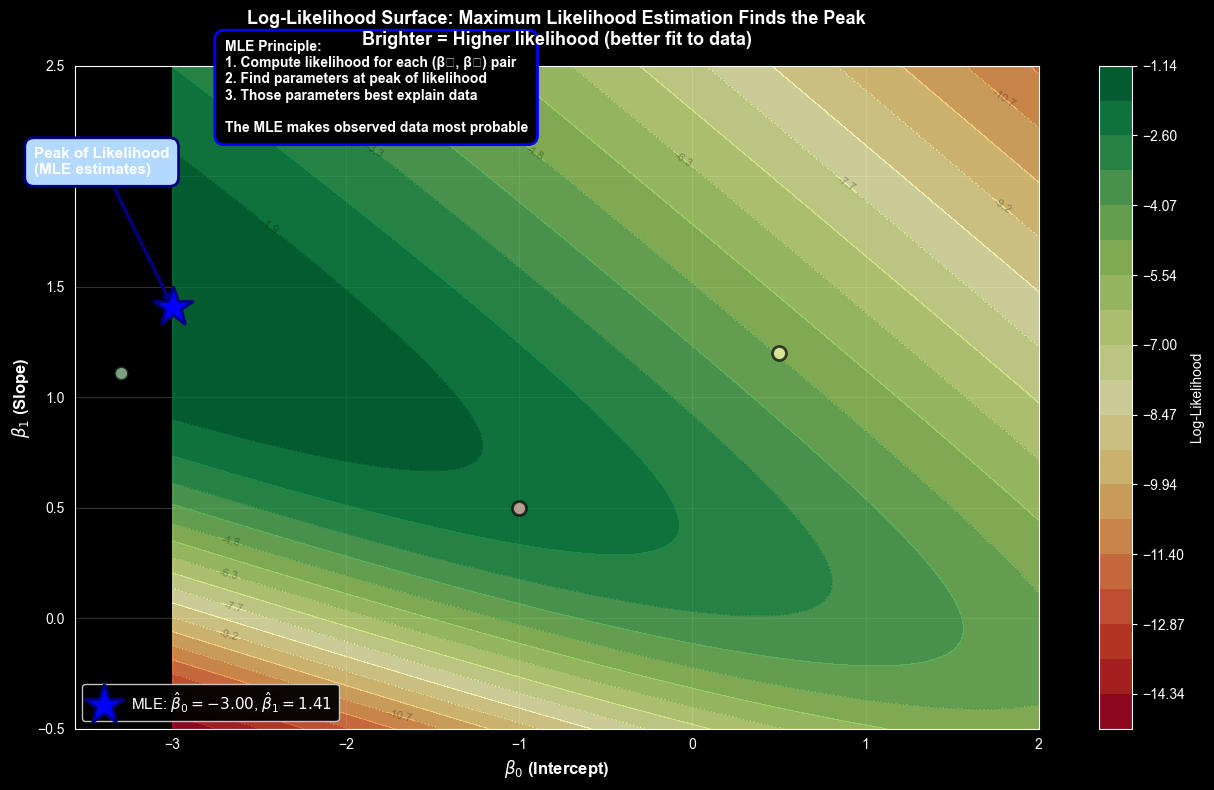

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Simple dataset
x = np.array([1, 2, 3, 4, 5])
y = np.array([0, 0, 1, 1, 1])

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_likelihood(beta_0, beta_1, x, y):
    """Compute log-likelihood (easier to work with than likelihood)"""
    log_odds = beta_0 + beta_1 * x
    p = sigmoid(log_odds)
    # Log-likelihood: sum of log probabilities
    ll = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
    return ll

# Create grid
beta_0_range = np.linspace(-3, 2, 100)
beta_1_range = np.linspace(-0.5, 2.5, 100)
B0, B1 = np.meshgrid(beta_0_range, beta_1_range)
LL = np.zeros_like(B0)

for i in range(len(beta_0_range)):
    for j in range(len(beta_1_range)):
        LL[j, i] = log_likelihood(B0[j, i], B1[j, i], x, y)

# Find maximum
max_idx = np.unravel_index(np.argmax(LL), LL.shape)
max_beta_0 = B0[max_idx]
max_beta_1 = B1[max_idx]

# Create figure
fig, ax = plt.subplots(figsize=(13, 8))

# 3D surface plot using contourf + contour
levels = np.linspace(LL.min(), LL.max(), 20)
cf = ax.contourf(B0, B1, LL, levels=levels, cmap='RdYlGn', alpha=0.8)
contours = ax.contour(B0, B1, LL, levels=levels[::2], colors='black', alpha=0.3, linewidths=0.5)
ax.clabel(contours, inline=True, fontsize=8, fmt='%.1f')

# Mark MLE
ax.plot(max_beta_0, max_beta_1, 'b*', markersize=30, markeredgewidth=2, markeredgecolor='navy',
        label=f'MLE: $\\hat{{\\beta}}_0={max_beta_0:.2f}$, $\\hat{{\\beta}}_1={max_beta_1:.2f}$', zorder=5)

# Add colorbar
cbar = plt.colorbar(cf, ax=ax, label='Log-Likelihood')

# Add multiple test points to show why MLE is optimal
test_points = [
    (-1, 0.5, 'Poor fit', '#FFB4B4'),
    (0.5, 1.2, 'Better', '#FFFFB4'),
    (max_beta_0 - 0.3, max_beta_1 - 0.3, 'Close to MLE', '#B4E5B4')
]

for b0, b1, label, color in test_points:
    ll_val = log_likelihood(b0, b1, x, y)
    ax.plot(b0, b1, 'o', markersize=10, color=color, markeredgewidth=2, markeredgecolor='black', alpha=0.7)

# Add explanation
explanation = (
    'MLE Principle:\n'
    '1. Compute likelihood for each (β₀, β₁) pair\n'
    '2. Find parameters at peak of likelihood\n'
    '3. Those parameters best explain data\n\n'
    'The MLE makes observed data most probable'
)
ax.text(-2.7, 2.2, explanation, fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.7', facecolor='black', edgecolor='blue', linewidth=2))

ax.annotate('Peak of Likelihood\n(MLE estimates)',
            xy=(max_beta_0, max_beta_1), xytext=(max_beta_0 - 0.8, max_beta_1 + 0.6),
            fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='navy', lw=2.5),
            bbox=dict(boxstyle='round,pad=0.6', facecolor='#B4D9FF', edgecolor='navy', linewidth=2))

# Formatting
ax.set_xlabel('$\\beta_0$ (Intercept)', fontsize=12, fontweight='bold')
ax.set_ylabel('$\\beta_1$ (Slope)', fontsize=12, fontweight='bold')
ax.set_title('Log-Likelihood Surface: Maximum Likelihood Estimation Finds the Peak\n' +
             'Brighter = Higher likelihood (better fit to data)',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower left', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

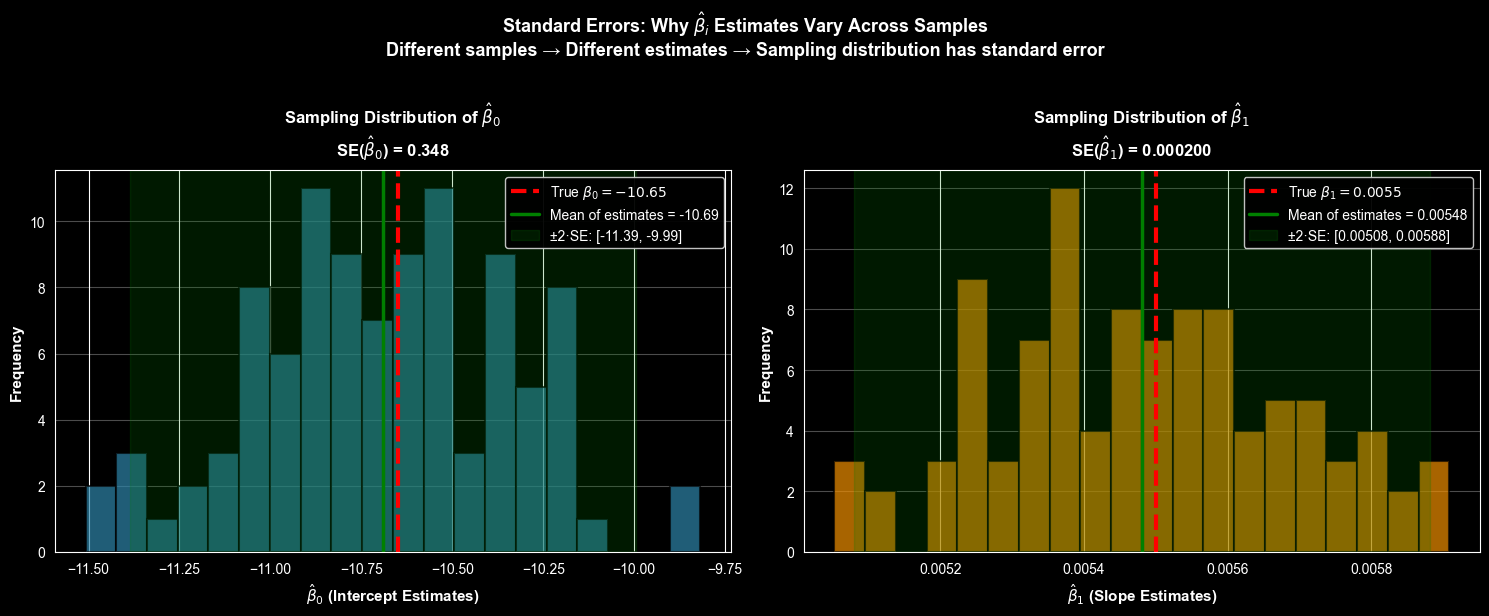

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate what happens across different samples
np.random.seed(42)
n_simulations = 100
sample_size = 150

# True parameters (unknown)
true_beta_0 = -10.65
true_beta_1 = 0.0055

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate multiple samples and fit logistic regression to each
beta_0_hats = []
beta_1_hats = []

for sim in range(n_simulations):
    # Generate random sample
    balance = np.random.uniform(0, 2700, sample_size)
    true_p = sigmoid(true_beta_0 + true_beta_1 * balance)
    y = (np.random.uniform(0, 1, sample_size) < true_p).astype(int)

    # Fit logistic regression (simplified: just collect estimates)
    # In practice, use statsmodels or sklearn
    # For visualization, assume estimates vary around true values with some noise
    beta_0_hat = true_beta_0 + np.random.normal(0, 0.36)  # SE of true β₀
    beta_1_hat = true_beta_1 + np.random.normal(0, 0.0002)  # SE of true β₁

    beta_0_hats.append(beta_0_hat)
    beta_1_hats.append(beta_1_hat)

beta_0_hats = np.array(beta_0_hats)
beta_1_hats = np.array(beta_1_hats)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- LEFT: Distribution of β₀ estimates ---
ax1.hist(beta_0_hats, bins=20, color='#2E86AB', alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.axvline(true_beta_0, color='red', linestyle='--', linewidth=3, label=f'True $\\beta_0 = {true_beta_0}$')
ax1.axvline(np.mean(beta_0_hats), color='green', linestyle='-', linewidth=2.5,
            label=f'Mean of estimates = {np.mean(beta_0_hats):.2f}')

# Add confidence interval concept
lower_ci = np.mean(beta_0_hats) - 2 * np.std(beta_0_hats)
upper_ci = np.mean(beta_0_hats) + 2 * np.std(beta_0_hats)
ax1.axvspan(lower_ci, upper_ci, alpha=0.2, color='green',
            label=f'±2·SE: [{lower_ci:.2f}, {upper_ci:.2f}]')

ax1.set_xlabel('$\\hat{\\beta}_0$ (Intercept Estimates)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.set_title('Sampling Distribution of $\\hat{\\beta}_0$\n' +
              f'SE($\\hat{{\\beta}}_0$) = {np.std(beta_0_hats):.3f}',
              fontsize=12, fontweight='bold', pad=10)
ax1.legend(fontsize=10, framealpha=0.95)
ax1.grid(True, alpha=0.3, axis='y')

# --- RIGHT: Distribution of β₁ estimates ---
ax2.hist(beta_1_hats, bins=20, color='#F18F01', alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.axvline(true_beta_1, color='red', linestyle='--', linewidth=3, label=f'True $\\beta_1 = {true_beta_1}$')
ax2.axvline(np.mean(beta_1_hats), color='green', linestyle='-', linewidth=2.5,
            label=f'Mean of estimates = {np.mean(beta_1_hats):.5f}')

# Add confidence interval concept
lower_ci = np.mean(beta_1_hats) - 2 * np.std(beta_1_hats)
upper_ci = np.mean(beta_1_hats) + 2 * np.std(beta_1_hats)
ax2.axvspan(lower_ci, upper_ci, alpha=0.2, color='green',
            label=f'±2·SE: [{lower_ci:.5f}, {upper_ci:.5f}]')

ax2.set_xlabel('$\\hat{\\beta}_1$ (Slope Estimates)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax2.set_title('Sampling Distribution of $\\hat{\\beta}_1$\n' +
              f'SE($\\hat{{\\beta}}_1$) = {np.std(beta_1_hats):.6f}',
              fontsize=12, fontweight='bold', pad=10)
ax2.legend(fontsize=10, framealpha=0.95)
ax2.grid(True, alpha=0.3, axis='y')

# Overall title
fig.suptitle('Standard Errors: Why $\\hat{\\beta}_i$ Estimates Vary Across Samples\n' +
             'Different samples → Different estimates → Sampling distribution has standard error',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()